In [6]:
import sys
import os
import numpy as np
import pretty_midi
import torch

notebook_dir = os.getcwd()
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..')))

import config as C
from lstm import MusicLSTM
from music import generate_music, notes_to_midi, prepend_seed_to_midi

In [7]:
model = MusicLSTM(
    pitch_embed_dim=C.PITCH_EMBED_DIM,
    hidden_size=C.HIDDEN_SIZE,
    num_layers=C.NUM_LAYERS,
    dropout=C.DROPOUT,
)
model.load_state_dict(torch.load(C.MODEL_PATH, map_location='cpu'))
model.eval()
print(model)

MusicLSTM(
  (pitch_embed): Embedding(128, 32)
  (lstm): LSTM(34, 512, num_layers=2, batch_first=True, dropout=0.3)
  (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (pitch_head): Linear(in_features=512, out_features=128, bias=True)
  (step_head): Linear(in_features=512, out_features=1, bias=True)
  (dur_head): Linear(in_features=512, out_features=1, bias=True)
)


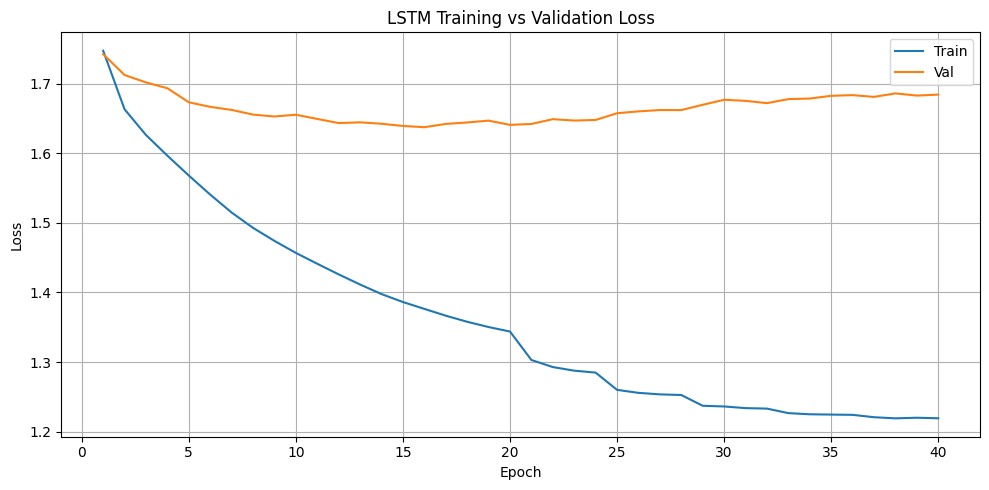

In [12]:
import json
import matplotlib.pyplot as plt

with open(C.LOSS_LOG) as f:
    log = json.load(f)

epochs = range(1, len(log["train"]) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, log["train"], label="Train")
plt.plot(epochs, log["val"],   label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Processing: /Users/emircalvillo/development/MyProjects/DL-Music-Generation/scripts/../maestro/2011/MIDI-Unprocessed_15_R1_2011_MID--AUDIO_R1-D6_09_Track09_wav.midi
Processing: /Users/emircalvillo/development/MyProjects/DL-Music-Generation/scripts/../maestro/2011/MIDI-Unprocessed_09_R1_2011_MID--AUDIO_R1-D3_15_Track15_wav.midi
Processing: /Users/emircalvillo/development/MyProjects/DL-Music-Generation/scripts/../maestro/2011/MIDI-Unprocessed_04_R3_2011_MID--AUDIO_R3-D2_05_Track05_wav.midi
Processing: /Users/emircalvillo/development/MyProjects/DL-Music-Generation/scripts/../maestro/2011/MIDI-Unprocessed_15_R1_2011_MID--AUDIO_R1-D6_10_Track10_wav.midi
Processing: /Users/emircalvillo/development/MyProjects/DL-Music-Generation/scripts/../maestro/2011/MIDI-Unprocessed_16_R1_2011_MID--AUDIO_R1-D6_15_Track15_wav.midi
Processing: /Users/emircalvillo/development/MyProjects/DL-Music-Generation/scripts/../maestro/2011/MIDI-Unprocessed_03_R3_2011_MID--AUDIO_R3-D1_04_Track04_wav.midi
Processing: /Use

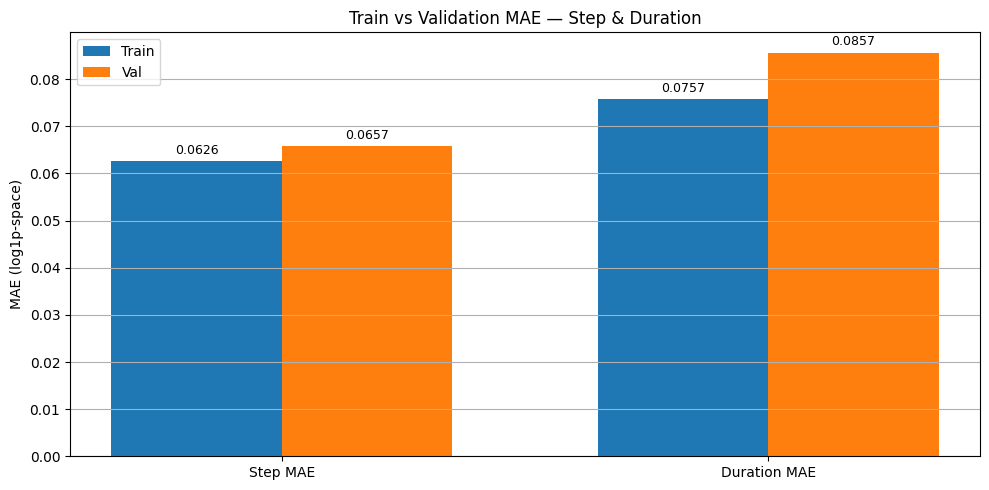

In [13]:
from data_import import load_data

train_loader, val_loader = load_data(
    year=C.YEAR, num_files=C.NUM_FILES,
    seq_length=C.SEQ_LENGTH, batch_size=C.BATCH_SIZE,
    val_split=C.VAL_SPLIT,
)

def compute_mae(loader):
    step_mae = dur_mae = n = 0
    model.eval()
    with torch.no_grad():
        for batch_x, _, b_step, b_dur in loader:
            _, s_pred, d_pred = model(batch_x)
            step_mae += (s_pred - b_step).abs().sum().item()
            dur_mae  += (d_pred - b_dur).abs().sum().item()
            n        += len(batch_x)
    return step_mae / n, dur_mae / n

train_step_mae, train_dur_mae = compute_mae(train_loader)
val_step_mae,   val_dur_mae   = compute_mae(val_loader)

print(f"Train — Step MAE: {train_step_mae:.4f} | Duration MAE: {train_dur_mae:.4f}")
print(f"Val   — Step MAE: {val_step_mae:.4f}   | Duration MAE: {val_dur_mae:.4f}")

labels  = ["Step MAE", "Duration MAE"]
train_v = [train_step_mae, train_dur_mae]
val_v   = [val_step_mae,   val_dur_mae]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, train_v, w, label="Train")
ax.bar(x + w/2, val_v,   w, label="Val")

for i, (tv, vv) in enumerate(zip(train_v, val_v)):
    ax.text(i - w/2, tv + 0.001, f"{tv:.4f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + w/2, vv + 0.001, f"{vv:.4f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("MAE (log1p-space)")
ax.set_title("Train vs Validation MAE — Step & Duration")
ax.legend()
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
def load_seed(midi_path, seq_length):
    pm    = pretty_midi.PrettyMIDI(midi_path)
    notes = sorted(pm.instruments[0].notes, key=lambda n: n.start)
    prev, data = notes[0].start, []
    for n in notes:
        # log1p matches the format used during training (see data_import.py)
        data.append([n.pitch / 127.0, np.log1p(n.start - prev), np.log1p(n.end - n.start)])
        prev = n.start
    return np.array(data[:seq_length], dtype=np.float32)

seed = load_seed(C.SEED_MIDI, C.SEQ_LENGTH)

os.makedirs(os.path.dirname(C.OUTPUT_MIDI), exist_ok=True)
generated = generate_music(
    model, seed,
    num_to_generate=C.NUM_TO_GENERATE,
    temperature=C.TEMPERATURE,
    min_step=C.MIN_STEP,
    min_dur=C.MIN_DUR
)
notes_to_midi(generated, C.OUTPUT_MIDI)
print(f"Saved to {C.OUTPUT_MIDI}")

Saved to /Users/emircalvillo/development/MyProjects/DL-Music-Generation/scripts/LSTM/generated_music/lstm_output2.mid


In [ ]:
combined = prepend_seed_to_midi(C.SEED_MIDI, C.OUTPUT_MIDI, seq_length=C.SEQ_LENGTH)
print(f"Saved to {combined}")

Saved to /Users/emircalvillo/development/MyProjects/DL-Music-Generation/scripts/LSTM/generated_music/lstm_output2_with_seed.mid
